# Visualization — saved BM4 Poincare section

This notebook reads the completed calculation in `resultados/<RUN_ID>/`.
It does not load the field, import an integrator, or recompute trajectories.
It can run on your laptop after downloading the result directory from AWS.
Keep the whole study folder and install `requirements.txt`.

Choose the calculation run ID below, or use `None` to read the latest completed
production run. Figures and the offline HTML viewer are saved separately under
`figuras/<RUN_ID>/`, leaving the numerical results untouched.

This study uses sixteen parallel worker processes. Their timing records are plotted below.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
from IPython.display import HTML, Markdown, display
import json
from study_io import ROOT, load_calculation

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 180, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

In [2]:
# Set, for example, RUN_ID = 'aws_100cycles', or keep None for latest success.
RUN_ID = os.environ.get('POINCARE_RUN_ID') or None

In [3]:
RESULTS, metadata, arrays, cycle_positions, initial_positions = load_calculation(RUN_ID)
RUN_ID = RESULTS.name
N_PARTICLES = metadata['particle_count']
N_CYCLES = metadata['cycles']
STEPS_PER_CYCLE = metadata['steps_per_cycle']
N_STEPS = metadata['complete_steps']
CYCLE_DURATION = metadata['cycle_duration']
FIELD_PROVENANCE = metadata['field_provenance']
L = FIELD_PROVENANCE['grid']['period']
CENTER = np.array([FIELD_PROVENANCE['grid']['x0'], FIELD_PROVENANCE['grid']['y0']]) + L/2
TIME_SCALE_S = metadata['time_scale_s']
times = arrays['times']
states = arrays['states']
cycle_times = arrays['cycle_times']
cycle_xy = arrays['cycle_positions']
cycle_xy_wrapped = arrays['cycle_positions_wrapped']
section_xy = cycle_xy_wrapped[1:]
initial_xy = arrays['initial_positions']
PARTICLE_IDS = arrays['particle_ids']
COLORS = arrays['colors_rgba']
COLOR_HEX = arrays['colors_hex'].tolist()
PARTICLE_CMAP = ListedColormap(COLORS)
PARTICLE_NORM = BoundaryNorm(np.arange(0.5, N_PARTICLES + 1.5), N_PARTICLES)

assert states.shape == (2*N_PARTICLES, N_STEPS+1)
assert cycle_xy.shape == cycle_xy_wrapped.shape == (N_CYCLES+1, N_PARTICLES, 2)
assert N_STEPS == N_CYCLES * STEPS_PER_CYCLE
assert np.all(np.isfinite(states)) and len(cycle_positions) == N_CYCLES*N_PARTICLES
assert len(initial_positions) == N_PARTICLES and len(COLOR_HEX) == N_PARTICLES
np.testing.assert_array_equal(PARTICLE_IDS, np.arange(1, N_PARTICLES+1))
np.testing.assert_array_equal(cycle_times, times[::STEPS_PER_CYCLE])
np.testing.assert_array_equal(cycle_xy[..., 0], states[:N_PARTICLES, ::STEPS_PER_CYCLE].T)
np.testing.assert_array_equal(cycle_xy[..., 1], states[N_PARTICLES:, ::STEPS_PER_CYCLE].T)
assert set(cycle_positions['cycle']) == set(range(1, N_CYCLES+1))
assert not cycle_positions.duplicated(['cycle', 'particle']).any()
assert np.all(cycle_positions.groupby('particle').size().to_numpy() == N_CYCLES)
assert np.all(cycle_positions.groupby('particle')['color'].nunique().to_numpy() == 1)
for particle, color in zip(PARTICLE_IDS, COLOR_HEX):
    assert metadata['colours'][str(particle)] == color
    assert (cycle_positions.loc[cycle_positions.particle == particle, 'color'] == color).all()

OUTPUT = ROOT / 'figuras' / RUN_ID
OUTPUT.mkdir(parents=True, exist_ok=True)
display(Markdown(f'**Run `{RUN_ID}`:** {N_PARTICLES} particles, {N_CYCLES} cycles, '
                 f'{STEPS_PER_CYCLE} steps/cycle; {len(cycle_positions)} section points.'))
if metadata.get('validation_run', False):
    display(Markdown('**Short validation run — not the requested 5,000-cycle production result.**'))
print('Verified numerical files:', RESULTS)
print('Figure output:', OUTPUT)

**Run `checkpoint_resume_test`:** 48 particles, 2 cycles, 20 steps/cycle; 96 section points.

**Short validation run — not the requested 5,000-cycle production result.**

Verified numerical files: /home/juan/Proyectos/GC2D_intranet/notebooks/developements/poincare_section/Poincare_BM4_48_radiales_5000_ciclos_20_steps_16_procesos_spot/resultados/checkpoint_resume_test
Figure output: /home/juan/Proyectos/GC2D_intranet/notebooks/developements/poincare_section/Poincare_BM4_48_radiales_5000_ciclos_20_steps_16_procesos_spot/figuras/checkpoint_resume_test


## Initial radial configuration

The saved colour mapping is reused for every particle in all plots and tables.
Spatial radii and gyro-radius are different quantities. The particles start
along one radius and subsequently follow the guiding-centre field freely.

,cycle,time_normalized,time_s,particle,color,initial_radius_over_L,x_unwrapped,y_unwrapped,x_wrapped,y_wrapped,x_over_L,y_over_L,R_wrapped_m,Z_wrapped_m
0,0,0,0,1,#372466,0.000000,9.424778,9.424778,9.424778,9.424778,0.500000,0.5,0.090703,0.090352
1,0,0,0,2,#3c3286,0.010426,9.621295,9.424778,9.621295,9.424778,0.510426,0.5,0.092580,0.090352
2,0,0,0,3,#4040a2,0.020851,9.817811,9.424778,9.817811,9.424778,0.520851,0.5,0.094456,0.090352
3,0,0,0,4,#434eba,0.031277,10.014328,9.424778,10.014328,9.424778,0.531277,0.5,0.096333,0.090352
4,0,0,0,5,#455ed3,0.041702,10.210845,9.424778,10.210845,9.424778,0.541702,0.5,0.098210,0.090352
5,0,0,0,6,#466be3,0.052128,10.407361,9.424778,10.407361,9.424778,0.552128,0.5,0.100086,0.090352
6,0,0,0,7,#4778f0,0.062553,10.603878,9.424778,10.603878,9.424778,0.562553,0.5,0.101963,0.090352
7,0,0,0,8,#4685fa,0.072979,10.800394,9.424778,10.800394,9.424778,0.572979,0.5,0.103839,0.090352
8,0,0,0,9,#4391fe,0.083404,10.996911,9.424778,10.996911,9.424778,0.583404,0.5,0.105716,0.090352
9,0,0,0,10,#3d9efe,0.093830,11.193428,9.424778,11.193428,9.424778,0.593830,0.5,0.107592,0.090352


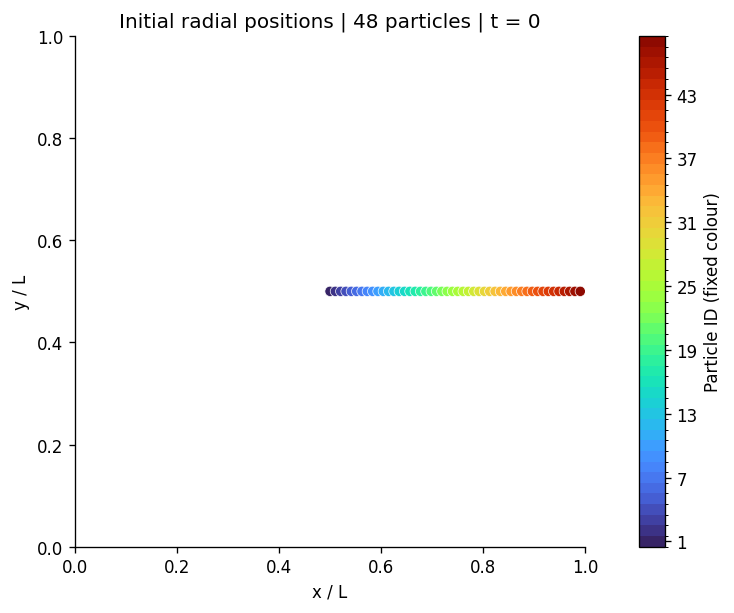

In [4]:
display(initial_positions)
fig, ax = plt.subplots(figsize=(8, 5), layout='constrained')
ax.plot([CENTER[0] / L, initial_xy[-1, 0] / L],
        [CENTER[1] / L, initial_xy[-1, 1] / L], color='0.75', lw=1, zorder=1)
ax.scatter(initial_xy[:, 0] / L, initial_xy[:, 1] / L, c=COLORS,
           s=38, edgecolors='white', linewidths=0.4, zorder=2)
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel='x / L', ylabel='y / L',
       title=f'Initial radial positions | {N_PARTICLES} particles | t = 0')
ax.set_aspect('equal')
fig.colorbar(ScalarMappable(norm=PARTICLE_NORM, cmap=PARTICLE_CMAP),
             ax=ax, label='Particle ID (fixed colour)', ticks=PARTICLE_IDS[::max(1, N_PARTICLES // 8)])
fig.savefig(OUTPUT / 'initial_positions.png', bbox_inches='tight')
plt.show()
plt.close(fig)

## Poincare section

Every dot below is the position at the end of a complete forcing cycle.
Colours identify particles and do not encode time. The main plot excludes
cycle zero. Coordinates are wrapped into the periodic base cell for display;
the unwrapped positions are retained in the numerical data. Opposite edges
represent adjacent points of the periodic domain. Points are not connected by
straight lines across these edges.

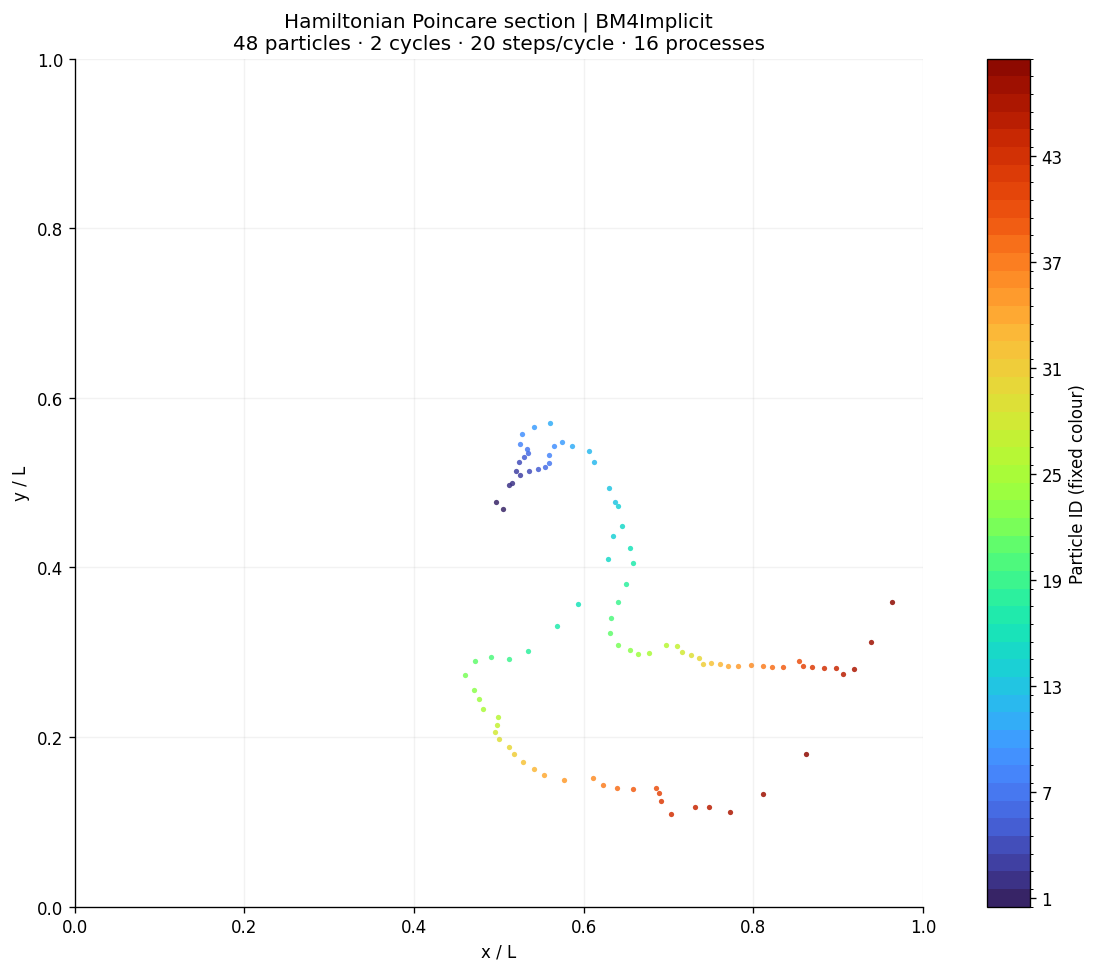

In [5]:
fig, ax = plt.subplots(figsize=(10, 8), layout='constrained')
for particle in range(N_PARTICLES):
    ax.scatter(section_xy[:, particle, 0] / L, section_xy[:, particle, 1] / L,
               color=COLORS[particle], s=10, alpha=0.85, linewidths=0)
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel='x / L', ylabel='y / L',
       title=f'Hamiltonian Poincare section | BM4Implicit\n'
             f'{N_PARTICLES} particles · {N_CYCLES} cycles · {STEPS_PER_CYCLE} steps/cycle · 16 processes')
ax.set_aspect('equal')
ax.grid(alpha=0.16)
fig.colorbar(ScalarMappable(norm=PARTICLE_NORM, cmap=PARTICLE_CMAP), ax=ax,
             label='Particle ID (fixed colour)',
             ticks=PARTICLE_IDS[::max(1, N_PARTICLES // 8)])
fig.savefig(OUTPUT / 'poincare_section.png', bbox_inches='tight')
fig.savefig(OUTPUT / 'poincare_section.svg', bbox_inches='tight')
plt.show()
plt.close(fig)

## Positions after each cycle

`cycle_positions` contains exactly one row for each particle and completed
cycle. `positions_at_cycle(k)` returns the 48 positions after cycle `k`;
`k=0` returns the initial configuration. Both the raw numerical coordinates
and their wrapped representatives are provided. SI positions are reconstructed
using the original HDF5 coordinate origin.

In [6]:
all_cycle_positions = pd.concat([initial_positions, cycle_positions], ignore_index=True)

def positions_at_cycle(cycle):
    """Return one complete particle table at a validated integer return index."""
    if isinstance(cycle, (bool, np.bool_)) or not isinstance(cycle, (int, np.integer)):
        raise ValueError('Cycle must be an integer.')
    if not 0 <= cycle <= N_CYCLES:
        raise ValueError(f'Cycle must be between 0 and {N_CYCLES}.')
    return all_cycle_positions.loc[all_cycle_positions['cycle'] == cycle].reset_index(drop=True)

display(positions_at_cycle(N_CYCLES))

,cycle,time_normalized,time_s,particle,color,initial_radius_over_L,x_unwrapped,y_unwrapped,x_wrapped,y_wrapped,x_over_L,y_over_L,R_wrapped_m,Z_wrapped_m
0,2,2,0.005227,1,#372466,0.000000,9.518926,8.847427,9.518926,8.847427,0.504995,0.469371,0.091602,0.084838
1,2,2,0.005227,2,#3c3286,0.010426,9.725913,9.421527,9.725913,9.421527,0.515976,0.499828,0.093579,0.090321
2,2,2,0.005227,3,#4040a2,0.020851,9.796755,9.692043,9.796755,9.692043,0.519734,0.514179,0.094255,0.092904
3,2,2,0.005227,4,#434eba,0.031277,9.869709,9.877787,9.869709,9.877787,0.523604,0.524033,0.094952,0.094677
4,2,2,0.005227,5,#455ed3,0.041702,9.978793,9.995142,9.978793,9.995142,0.529391,0.530259,0.095994,0.095798
5,2,2,0.005227,6,#466be3,0.052128,10.078434,10.076919,10.078434,10.076919,0.534678,0.534597,0.096945,0.096579
6,2,2,0.005227,7,#4778f0,0.062553,10.060241,10.162149,10.060241,10.162149,0.533712,0.539119,0.096771,0.097393
7,2,2,0.005227,8,#4685fa,0.072979,9.893625,10.285424,9.893625,10.285424,0.524873,0.545659,0.095180,0.098570
8,2,2,0.005227,9,#4391fe,0.083404,9.938569,10.493758,9.938569,10.493758,0.527257,0.556711,0.095609,0.100560
9,2,2,0.005227,10,#3d9efe,0.093830,10.196944,10.665105,10.196944,10.665105,0.540965,0.565801,0.098077,0.102196


## Cycle viewer

Move the slider or press Play. Large dots show the current cycle; the optional
small dots show the accumulated Poincare section. At cycle zero only the initial
positions are shown. The table gives the coordinates at the selected cycle.
The exported HTML viewer works offline in a browser without a Python kernel.

In [7]:
viewer_data = {
    'points': (cycle_xy_wrapped / L).tolist(), 'colors': COLOR_HEX,
    'cycles': N_CYCLES, 'particles': N_PARTICLES, 'period_s': TIME_SCALE_S,
    'L': L, 'cycle_duration': CYCLE_DURATION,
}
viewer_template = r"""<!doctype html>
<html lang="en"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">
<title>BM4 Poincare cycle viewer</title>
<style>
body{font:15px system-ui,sans-serif;margin:0;padding:20px;color:#183039;background:#f5f8fa}
.panel{max-width:1030px;margin:auto;background:white;border:1px solid #dce5e9;border-radius:12px;padding:20px}
h2{margin:0 0 6px;font-size:21px}p{color:#506872}.controls{display:flex;flex-wrap:wrap;gap:14px;align-items:center;margin:18px 0}
button{background:#163e4c;color:white;border:0;padding:9px 18px;border-radius:6px;cursor:pointer}
.cycle-control{display:flex;align-items:center;gap:8px}.cycle-step{min-width:34px;padding:7px 10px;font-size:16px;line-height:1}
input[type=range]{width:min(380px,60vw)}.grid{display:grid;grid-template-columns:minmax(290px,2fr) minmax(220px,1fr);gap:22px}
canvas{width:100%;aspect-ratio:1;background:white}.tablebox{max-hsixteen:560px;overflow:auto}
table{width:100%;border-collapse:collapse;font-size:13px;font-variant-numeric:tabular-nums}
th,td{padding:6px;text-align:right;border-bottom:1px solid #e7edf0}th{position:sticky;top:0;background:white}
td:first-child,th:first-child{text-align:left}.dot{display:inline-block;width:11px;hsixteen:11px;border-radius:50%;margin-right:7px}
@media(max-width:650px){.grid{grid-template-columns:1fr}.tablebox{max-hsixteen:250px}}
</style></head><body><div class="panel">
<h2>Hamiltonian Poincare section · BM4Implicit</h2>
<p id="summary"></p><div class="controls">
<button id="play">Play</button><span class="cycle-control"><button class="cycle-step" id="cycle-previous" type="button" aria-label="Previous cycle">−</button><label>Cycle <input id="cycle" aria-label="Cycle" type="range" min="0" step="1"></label><button class="cycle-step" id="cycle-next" type="button" aria-label="Next cycle">+</button></span>
<strong id="count"></strong><label><input id="history" type="checkbox" checked> Show previous returns</label></div>
<div class="grid"><canvas id="plot" width="900" hsixteen="900" aria-label="Poincare positions in the periodic cell"></canvas>
<div><p id="time"></p><div class="tablebox"><table><thead><tr><th>Particle</th><th>x / L</th><th>y / L</th></tr></thead><tbody id="rows"></tbody></table></div></div></div>
<p>Fixed colour per particle. Large points: current cycle. Small points: previous returns. Cycle 0: initial state.</p>
</div><script>
const data=__DATA__;
const slider=document.getElementById('cycle'),hist=document.getElementById('history'),button=document.getElementById('play');
const canvas=document.getElementById('plot'),ctx=canvas.getContext('2d');let timer=null;
slider.max=data.cycles;slider.value=data.cycles;
document.getElementById('summary').textContent=`${data.particles} radial particles · ${data.cycles} forcing cycles · one point per cycle`;
const left=80,plotTop=25,size=775;
function point(x,y,r,c,alpha){ctx.globalAlpha=alpha;ctx.fillStyle=c;ctx.beginPath();ctx.arc(left+x*size,plotTop+(1-y)*size,r,0,2*Math.PI);ctx.fill();ctx.globalAlpha=1;}
function draw(){const k=Number(slider.value);ctx.clearRect(0,0,900,900);ctx.lineWidth=1;ctx.font='19px system-ui';ctx.textAlign='center';
 for(let i=0;i<=4;i++){let u=i/4;ctx.strokeStyle='#e3eaee';ctx.beginPath();ctx.moveTo(left+u*size,plotTop);ctx.lineTo(left+u*size,plotTop+size);ctx.moveTo(left,plotTop+u*size);ctx.lineTo(left+size,plotTop+u*size);ctx.stroke();ctx.fillStyle='#448e69';ctx.fillText(u.toFixed(2),left+u*size,plotTop+size+31);ctx.fillText((1-u).toFixed(2),left-48,plotTop+u*size+7);}
 ctx.strokeStyle='#728995';ctx.strokeRect(left,plotTop,size,size);ctx.fillStyle='#183039';ctx.fillText('x / L',left+size/2,plotTop+size+68);ctx.save();ctx.translate(19,plotTop+size/2);ctx.rotate(-Math.PI/2);ctx.fillText('y / L',0,0);ctx.restore();
 if(hist.checked){for(let j=1;j<k;j++)for(let p=0;p<data.particles;p++){let xy=data.points[j][p];point(xy[0],xy[1],2.9,data.colors[p],.72);}}
 for(let p=0;p<data.particles;p++){let xy=data.points[k][p];point(xy[0],xy[1],6.2,'white',1);point(xy[0],xy[1],4.6,data.colors[p],1);}
 document.getElementById('count').textContent=`${k} / ${data.cycles}`;
 document.getElementById('time').textContent=`t = ${(k*data.cycle_duration).toFixed(2)} · ${(k*data.cycle_duration*data.period_s).toPrecision(6)} s`;
 document.getElementById('rows').innerHTML=data.points[k].map((xy,p)=>`<tr><td><span class="dot" style="background:${data.colors[p]}"></span>${p+1}</td><td>${xy[0].toFixed(7)}</td><td>${xy[1].toFixed(7)}</td></tr>`).join('');
}
function stop(){if(timer!==null){clearInterval(timer);timer=null;}button.textContent='Play';}
function stepCycle(delta){stop();slider.value=Math.max(0,Math.min(data.cycles,Number(slider.value)+delta));draw();}
document.getElementById('cycle-previous').onclick=()=>stepCycle(-1);
document.getElementById('cycle-next').onclick=()=>stepCycle(1);
slider.addEventListener('input',()=>{stop();draw();});hist.addEventListener('change',draw);
button.addEventListener('click',()=>{if(timer!==null){stop();return;}if(Number(slider.value)>=data.cycles)slider.value=0;draw();button.textContent='Pause';timer=setInterval(()=>{slider.value=Number(slider.value)+1;draw();if(Number(slider.value)>=data.cycles)stop();},180);});
draw();
</script></body></html>"""
viewer_html = viewer_template.replace('__DATA__', json.dumps(viewer_data, separators=(',', ':')))
(OUTPUT / 'poincare_cycle_viewer.html').write_text(viewer_html, encoding='utf-8')
# Isolate scripts/styles so repeated notebook displays do not share element IDs.
import html
display(HTML('<iframe title="Poincare cycle viewer" style="width:100%;hsixteen:850px;border:0" '
             'sandbox="allow-scripts" srcdoc="' + html.escape(viewer_html, quote=True) + '"></iframe>'))

/home/juan/Proyectos/GC2D_intranet/.venv/lib/python3.11/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## Interpretation and saved products

The section samples phase zero of the periodic forcing, not each particle's
orbital period. The numerical coordinates are wrapped only for display.
Colours identify particles throughout the 100 returns. The Hamiltonian depends
on time, so constant energy is not required. No reference trajectory or global
trajectory-error estimate was requested.

Figures: `initial_positions.png`, `poincare_section.png` and
`poincare_section.svg`. Interactive viewer: `poincare_cycle_viewer.html`.
The HTML file can be opened offline in a normal browser. For complete positions,
use `resultados/<RUN_ID>/positions_after_each_cycle.csv`.

## Parallel execution evidence

Each bar is one worker integration interval; colours identify workers only in this timing plot. Particle colours in the section remain fixed.

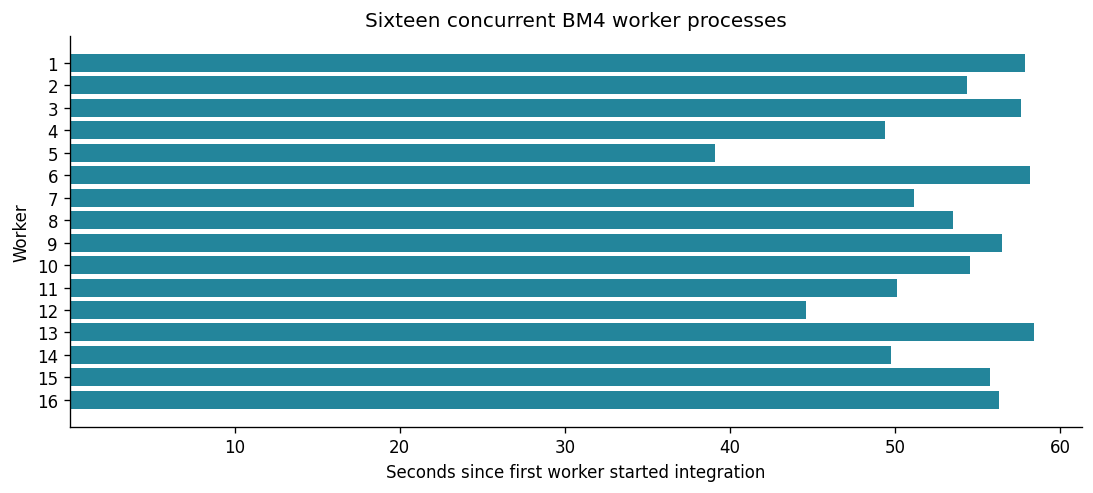

,worker,pid,particle_ids,integration_seconds,cpu_seconds
0,1,21764,"[1, 17, 33]",57.872736,21.998805
1,2,21768,"[2, 18, 34]",54.334911,22.139125
2,3,21765,"[3, 19, 35]",57.607351,22.244812
3,4,21773,"[4, 20, 36]",49.372886,18.232782
4,5,21762,"[5, 21, 37]",39.126218,16.494362
5,6,21771,"[6, 22, 38]",58.201467,21.422438
6,7,21767,"[7, 23, 39]",51.157930,21.349375
7,8,21775,"[8, 24, 40]",53.538611,19.610842
8,9,21761,"[9, 25, 41]",56.465075,22.861317
9,10,21770,"[10, 26, 42]",54.538019,19.921089


Parallel wall time including startup and merge: 62.91 s


In [8]:
workers = pd.DataFrame(metadata['workers'])
assert len(workers) == 16 and workers['pid'].nunique() == 16
origin = workers['started_monotonic_s'].min()
fig, ax = plt.subplots(figsize=(9, 4), layout='constrained')
ax.barh(workers['worker'], workers['integration_seconds'],
        left=workers['started_monotonic_s'] - origin, color='#23859b')
ax.set(xlabel='Seconds since first worker started integration', ylabel='Worker',
       yticks=workers['worker'], title='Sixteen concurrent BM4 worker processes')
ax.invert_yaxis()
fig.savefig(OUTPUT / 'parallel_execution.png', bbox_inches='tight')
plt.show()
plt.close(fig)
display(workers[['worker', 'pid', 'particle_ids', 'integration_seconds', 'cpu_seconds']])
print(f"Parallel wall time including startup and merge: {metadata['runtime_seconds']:.2f} s")


## Saved Newton convergence and multiplier norm
The summary uses every saved step. Plots of long histories use block maxima so peaks are retained. The lower-right panel displays actual Newton iteration histories for a solve with the largest correction count in each worker. Iteration zero is the initial guess. Complete, unaggregated records are available in the two compressed CSV files.


,worker,mean_newton_corrections,max_newton_corrections,total_newton_corrections,total_residual_evaluations,max_residual_over_tolerance,mu_inf_mean,mu_inf_rms,mu_inf_max,mu_inf_final
0,1,1.925,2,77,117,0.835426,0.000143,0.000192,0.000624,0.000360
1,2,1.850,2,74,114,0.821900,0.000125,0.000166,0.000370,0.000023
2,3,1.975,2,79,119,0.305684,0.000133,0.000174,0.000613,0.000086
3,4,2.000,2,80,120,0.000166,0.000108,0.000136,0.000405,0.000299
4,5,1.950,2,78,118,0.594623,0.000099,0.000121,0.000359,0.000224
5,6,1.950,2,78,118,0.910087,0.000133,0.000168,0.000558,0.000072
6,7,1.975,2,79,119,0.799443,0.000116,0.000133,0.000272,0.000156
7,8,2.000,2,80,120,0.000254,0.000118,0.000135,0.000270,0.000122
8,9,2.000,2,80,120,0.000360,0.000133,0.000161,0.000391,0.000113
9,10,1.975,2,79,119,0.498253,0.000129,0.000149,0.000383,0.000194


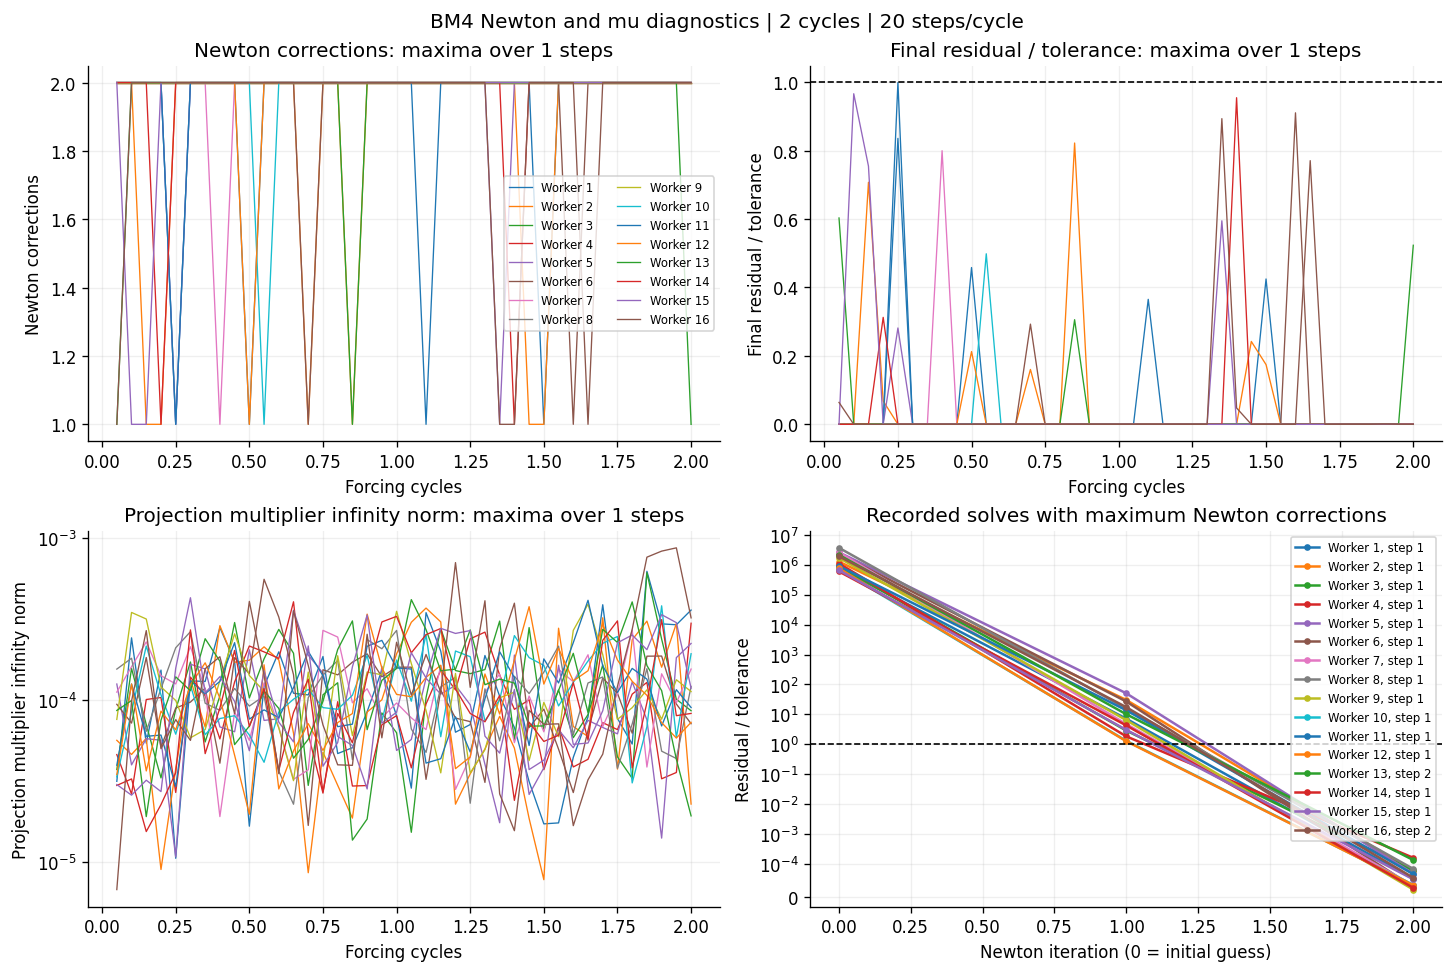

Full step diagnostics: /home/juan/Proyectos/GC2D_intranet/notebooks/developements/poincare_section/Poincare_BM4_48_radiales_5000_ciclos_20_steps_16_procesos_spot/resultados/checkpoint_resume_test/newton_steps.csv.gz
Full Newton iteration history: /home/juan/Proyectos/GC2D_intranet/notebooks/developements/poincare_section/Poincare_BM4_48_radiales_5000_ciclos_20_steps_16_procesos_spot/resultados/checkpoint_resume_test/newton_iterations.csv.gz


In [9]:
from diagnostic_plots import plot_diagnostics
display(pd.DataFrame(metadata["newton_mu_summary"]))
fig = plot_diagnostics(metadata, arrays, OUTPUT)
plt.show()
print("Full step diagnostics:", RESULTS / "newton_steps.csv.gz")
print("Full Newton iteration history:", RESULTS / "newton_iterations.csv.gz")


In [10]:
display(Markdown(f'**Visualization complete.** Products saved in `{OUTPUT}`. '
                 f'The calculation in `{RESULTS}` was read without integration.'))

**Visualization complete.** Products saved in `/home/juan/Proyectos/GC2D_intranet/notebooks/developements/poincare_section/Poincare_BM4_48_radiales_5000_ciclos_20_steps_16_procesos_spot/figuras/checkpoint_resume_test`. The calculation in `/home/juan/Proyectos/GC2D_intranet/notebooks/developements/poincare_section/Poincare_BM4_48_radiales_5000_ciclos_20_steps_16_procesos_spot/resultados/checkpoint_resume_test` was read without integration.